### Assignment: Detecting the Widest Mouth Open Frame in a Video

**Objective:**  
Detecting facial expressions and specific mouth movements, such as the widest opening, is a fundamental technique in computer vision and human-computer interaction. The mouth's movement is highly expressive, and analyzing it has become important in areas like emotion recognition, where open mouth gestures can signal surprise, joy, or vocal sounds.  In this assignment, please design a Python script that analyzes a video of a person talking. Your task is to output the frame where the person's mouth is open the widest.

**Requirements:**

1. **Input:**  
   - Your script should accept a video file (e.g., `.mp4`) containing a person speaking.

2. **Output:**  
   - Display the frame where the mouth is open the widest.
   - Show the index of this frame within the video.

3. **Additional Guidance:**  
   - Use the face detection algorithm to analyze each frame of the video and measure the openness of the mouth in each frame.

In [2]:
!pip install face_alignment

In [1]:
import face_alignment
import cv2
import numpy as np


In [2]:
import matplotlib.pyplot as plt
import torch

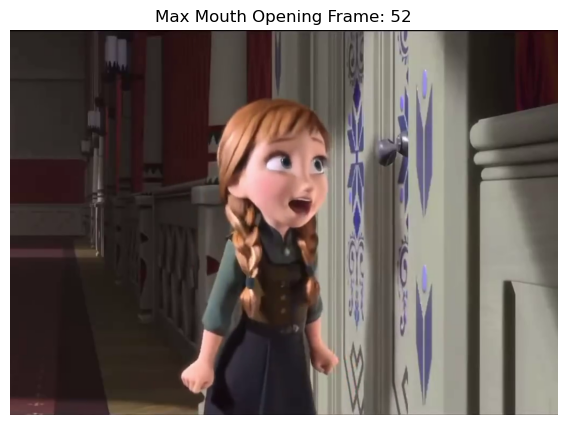

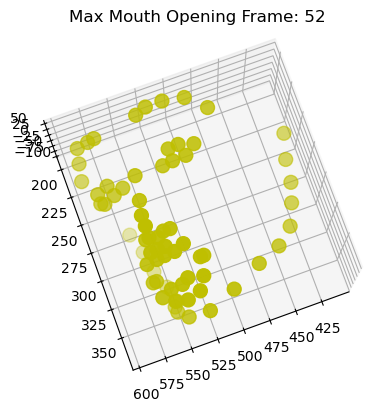

The frame where the person's mouth is open the widest: 52
Maximum mouth opening distance: 45.4771728515625


In [3]:
def get_mouth_opening(landmarks): # calculate the distance of up lip and low lip
    top_lip = landmarks[51] # middle up lip
    bottom_lip = landmarks[57] # middle down lip
    
    # calculate the Euclidean Distance
    mouth_opening = np.linalg.norm(top_lip - bottom_lip)
    return mouth_opening

def analyze_video(video_path):
    # Initialize face_alignment and use 3D feature point detection
    fa = face_alignment.FaceAlignment(face_alignment.LandmarksType.THREE_D, 
                                      device='cuda' if torch.cuda.is_available() else 'cpu', 
                                      flip_input=False)

    cap = cv2.VideoCapture(video_path)
    frame_number = 0 # read video frame by frame
    max_mouth_opening = 0
    max_frame_number = 0
    max_frame_image = None
    max_landmarks = None # find the largest mouth opening frame and record information

    while cap.isOpened():
        ret, frame = cap.read() #ret: Boolean value, ture or false for succesfully reading frame 
        if not ret:
            break

        # change BGR to RGB 
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # face feature point
        landmarks_list = fa.get_landmarks(rgb_frame)

        if landmarks_list is not None: #face detected
            # get the first face feature point
            landmarks = landmarks_list[0]

            # Calculate mouth opening and closing
            mouth_opening = get_mouth_opening(landmarks)

            # largest mouth open frame
            if mouth_opening > max_mouth_opening:
                max_mouth_opening = mouth_opening
                max_frame_number = frame_number
                max_frame_image = rgb_frame.copy()
                max_landmarks = landmarks

        frame_number += 1

    cap.release()

    # output max_mouth open frame
    if max_frame_image is not None:
        plt.figure(figsize=(10, 5))
        plt.imshow(max_frame_image)
        plt.axis('off')  
        plt.title(f"Max Mouth Opening Frame: {max_frame_number}")
        plt.show()

        # 3d image
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter3D(max_landmarks[:, 0], max_landmarks[:, 1], max_landmarks[:, 2], c='y', s=100)
        ax.view_init(elev=80, azim=70)
        plt.title(f"Max Mouth Opening Frame: {max_frame_number}")
        plt.show()
        print(f"The frame where the person's mouth is open the widest: {max_frame_number}")
        print(f"Maximum mouth opening distance: {max_mouth_opening}")

video_path = "test1.mp4" 
analyze_video(video_path)